In [1]:
# import os
# os.chdir("..")

In [2]:
import pandas as pd
import duckdb
from config.config import ANIME_DB_PATH

import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
aa = pd.read_csv("C:/Users/gonza/Downloads/archidekt-collection-export-2026-03-08.csv")
aa["aa"] = aa["Quantity"] * aa["Price (Card Market)"]
aa = aa.sort_values("aa", ascending=False)
aa["aa_cumsum"] = aa["aa"].cumsum()
aa["aa"].sum()

np.float64(140.81)

In [ ]:
aa[aa["aa_cumsum"] <= 240]["Quantity"].sum() / aa["Quantity"].sum()

np.float64(1.0)

: 

In [ ]:
anime_conn = duckdb.connect(database = ANIME_DB_PATH)

In [ ]:
# first_seasons_apothecary = [54492, 58514]
# anime_info = anime_conn.execute(f"select * from show_info where id in ({', '.join(map(str, first_seasons_apothecary))})").df()
# anime_episodes = anime_conn.execute(f"select * from anime_episodes where anime_id in ({', '.join(map(str, first_seasons_apothecary))})").df()

0. Basic stats and queries

In [82]:
initial_anime_id = 54492
anime_info = anime_conn.execute(f"select * from show_info where id = {initial_anime_id}").df()
anime_info
anime_conn.execute(f"""
                   select *
                   from show_relationships
                   where source_id = {initial_anime_id} or id = {initial_anime_id}
                   """).df()

,source_id,id,type,relation
0,54492,58514,anime,Sequel
1,54492,56975,anime,Other
2,54492,107562,manga,Adaptation
3,58514,54492,anime,Prequel
4,56975,54492,anime,Other


In [ ]:
anime_conn.execute(f"select * from show_relationships").df()

,source_id,id,type,relation
0,54492,58514,anime,Sequel
1,54492,56975,anime,Other
2,54492,107562,manga,Adaptation
3,58514,61987,anime,Sequel
4,58514,54492,anime,Prequel
5,58514,62844,anime,Side Story
6,58514,107562,manga,Adaptation
7,58514,60749,anime,Other
8,56975,60749,anime,Sequel
9,56975,54492,anime,Other


: 

In [78]:
anime_conn.execute(f"select * from show_info where id = 58514").df()

,id,type,title,title_english,title_japanese,source,episodes,aired_from,aired_to,duration,rating,score,scored_by,rank,popularity,members,favorites
0,58514,TV,Kusuriya no Hitorigoto 2nd Season,The Apothecary Diaries Season 2,薬屋のひとりごと 第2期,Light novel,24,2025-01-10,2025-07-04,24 min per ep,PG-13 - Teens 13 or older,8.91,239267,21,547,469656,7262


1. Various analyses on the first seasons

In [ ]:
def put_horizontal_line_for_overall_score(anime_info, anime_episodes):
    xmin, xmax = anime_episodes["id"].min(), anime_episodes["id"].max()
    xmin = xmin - 1 if xmin == 1 else xmin
    plt.axhline(xmin = xmin, xmax = xmax, y = anime_info["score"].iloc[0] / 2,
                color='r', linestyle='--', label='Overall Score'
            )

def plot_episode_scores(anime_info, anime_episodes, anime_hue = None):
    anime_episodes = anime_episodes.sort_values(["anime_id", "id"])
    anime_episodes["id"] = list(range(1, len(anime_episodes) + 1))
    plt.figure(figsize=(15, 5))
    sns.lineplot(data = anime_episodes, x = "id", y = "score", marker = "o", hue = anime_hue)
    if anime_hue:
        plt.legend(title = anime_hue.capitalize())
    if anime_hue:
        for hue_value in anime_episodes[anime_hue].unique():
            subset = anime_episodes[anime_episodes[anime_hue] == hue_value]
            subset_info = anime_info[anime_info["id"] == subset["anime_id"].iloc[0]]
            put_horizontal_line_for_overall_score(subset_info, subset)
    else:
        put_horizontal_line_for_overall_score(anime_info, anime_episodes)

    plt.title(f"Episode Scores for {anime_info['title'].iloc[0]}")
    plt.xlabel("Episode Number")
    plt.ylabel("Score")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

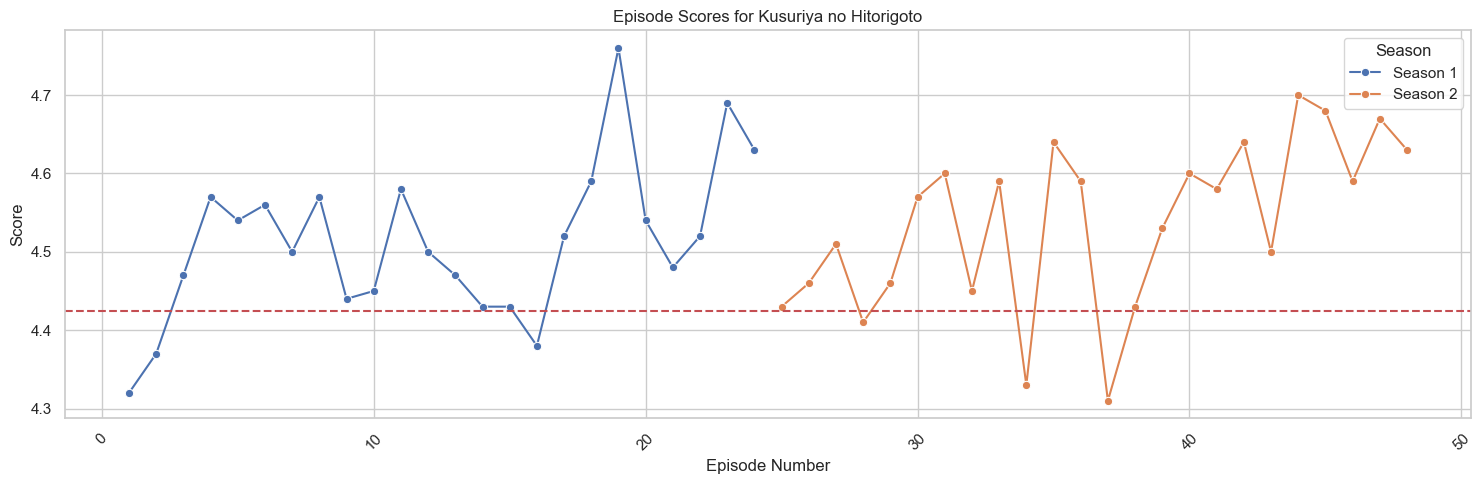

In [71]:
def hue_apothecary_seasons(data: pd.DataFrame):
    data["season"] = data["anime_id"].map(lambda x: "Season 1" if x == 54492 else "Season 2")

selected_anime_id = [54492, 58514]
anime_info_subset = anime_info[anime_info["id"].isin(selected_anime_id)]
anime_episodes_subset = anime_episodes[anime_episodes["anime_id"].isin(selected_anime_id)]

hue_apothecary_seasons(anime_episodes_subset)

plot_episode_scores(anime_info_subset, anime_episodes_subset, anime_hue = "season")
# plot_episode_scores(anime_info_subset, anime_episodes_subset)

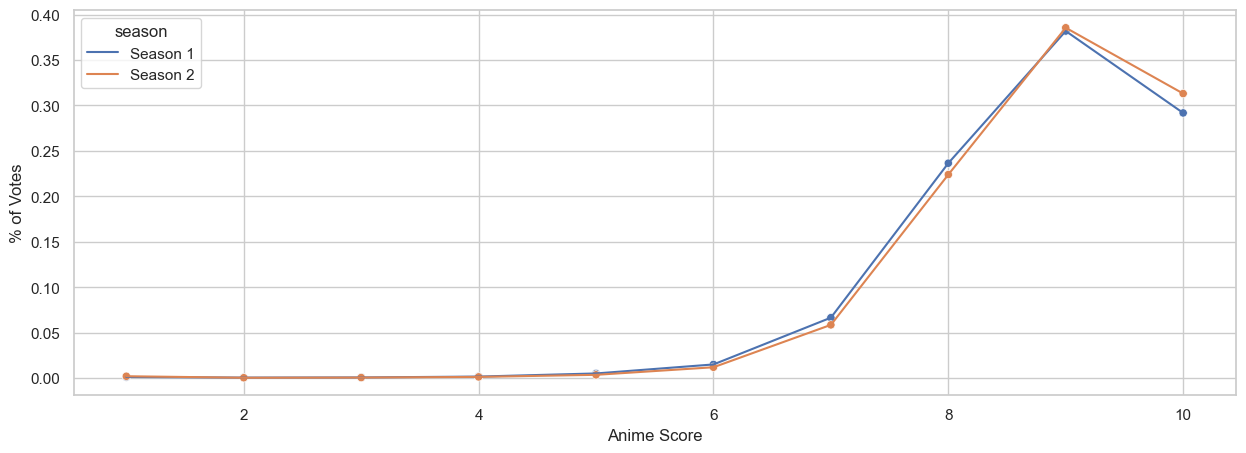

In [74]:
aa = anime_conn.execute(f"select * from anime_statistics where anime_id in ({', '.join(map(str, first_seasons_apothecary))})").df()
aa_score = aa[aa["kpi_name"] == "score"]
aa_score["amount_normalized"] = aa_score["amount"] / aa_score.groupby("anime_id")["amount"].transform("sum")
aa_score["score"] = aa_score["kpi_value"].str.split("_", expand = True)[1].astype(int)
hue_apothecary_seasons(aa_score)
plt.figure(figsize=(15, 5))
# sns.barplot(data = aa_score, x = "score", y = "amount_normalized", hue = "anime_id")
sns.lineplot(data = aa_score, x = "score", y = "amount_normalized", hue = "season")
sns.scatterplot(data = aa_score, x = "score", y = "amount_normalized", hue = "season",
                legend = False)
plt.xlabel("Anime Score")
plt.ylabel("% of Votes")
plt.show()

Review numbers analysis

In [6]:
anime_reaction_reviews_simple = anime_reaction_reviews.drop(
    columns = ["mal_id", "overall", "anime_id"])

perform clustering over anime_reaction_reviews_simple dataset. for that, use k-means with several cluster values (e.g., from 1 to 7). use a correlation distance metric for the distance matrix. perform evaluation of the created clusters using metrics any way you consider (e.g, using the silhouette coefficients). show the evaluation results for each number of clusters.

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples

# correlation distance matrix
metric = "correlation"
metric = "euclidean"
corr_dist = pairwise_distances(anime_reaction_reviews_simple, metric = metric)
# we have nans bc all values in some rows are the same.
# let's get  which data points are have all the same column values
if metric == "correlation":
    nan_points = anime_reaction_reviews_simple.index[anime_reaction_reviews_simple.nunique(axis=1) == 1].tolist()
    # let's go for each pair, if both are in nan_points, set value to 1, else 0
    for i in nan_points:
        for j in nan_points:
            if i != j: # don't fill the diagonal, else will throw error
                corr_dist[i][j] = 1.0
    # fill the rest of nans with 0
    corr_dist = np.nan_to_num(corr_dist, nan=0.0)

results = []
sil_samples_list = []
labels_list = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, random_state = 0)
    labels = kmeans.fit_predict(anime_reaction_reviews_simple)
    labels_list.append(labels)

    sil = silhouette_score(corr_dist, labels, metric = "precomputed")
    sil_samples_list.append(silhouette_samples(corr_dist, labels, metric = "precomputed"))
    results.append({"k": k, "silhouette_corr": sil})

results_df = pd.DataFrame(results)
display(results_df)

,k,silhouette_corr
0,2,0.954226
1,3,0.897359
2,4,0.892684
3,5,0.901165
4,6,0.902739
5,7,0.890975
6,8,0.887798
7,9,0.719055


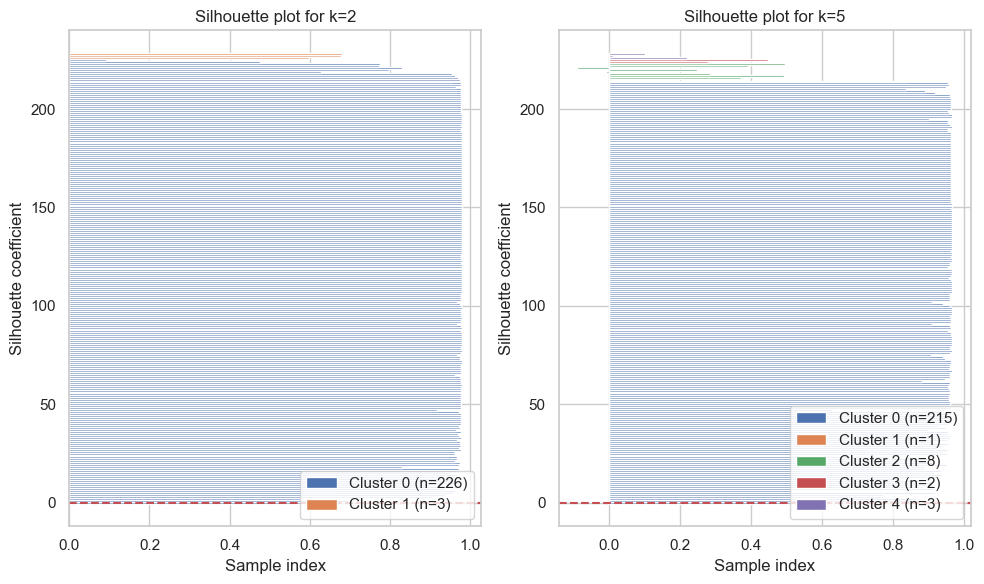

In [8]:
# please graph the silhouette scores for each sample, i want to divide it by label
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
n_plot = 1
for idx, sil_samples in enumerate(sil_samples_list):
    k = idx + 2
    if k not in [2, 5]:
        continue
    plt.subplot(1, 2, n_plot)
    n_plot += 1
    plt.title(f'Silhouette plot for k={k}')
    plt.xlabel('Sample index')
    plt.ylabel('Silhouette coefficient')
    plt.axhline(y=0, color='r', linestyle='--')
    
    # Sort by cluster label for better visualization
    sorted_indices = np.argsort(labels_list[idx])
    sorted_labels = labels_list[idx][sorted_indices]
    sorted_sil_samples = sil_samples[sorted_indices]
    
    # Plot with different colors for each cluster
    y_lower = 0
    for cluster_label in range(k):

        # Get silhouette values for this cluster
        cluster_sil_values = sorted_sil_samples[sorted_labels == cluster_label]
        cluster_size = cluster_sil_values.shape[0]
        
        y_upper = y_lower + cluster_size
        
        plt.barh(range(y_lower, y_upper), cluster_sil_values, height=1.0, 
                 label=f'Cluster {cluster_label} (n={cluster_size})')

        y_lower = y_upper
    plt.legend(loc='lower right')
    plt.tight_layout()
plt.show()

In [9]:
from dimensionality_reduction.pca_model import PCAModel
pca_model = PCAModel(anime_reaction_reviews_simple)
pca_model.fit(n_components = 7, preprocessing = "none")

# from sklearn.decomposition import PCA
# pca = PCA(n_components = 7) # we have more arguments!!!

First 6 components have eigenvalues > 1


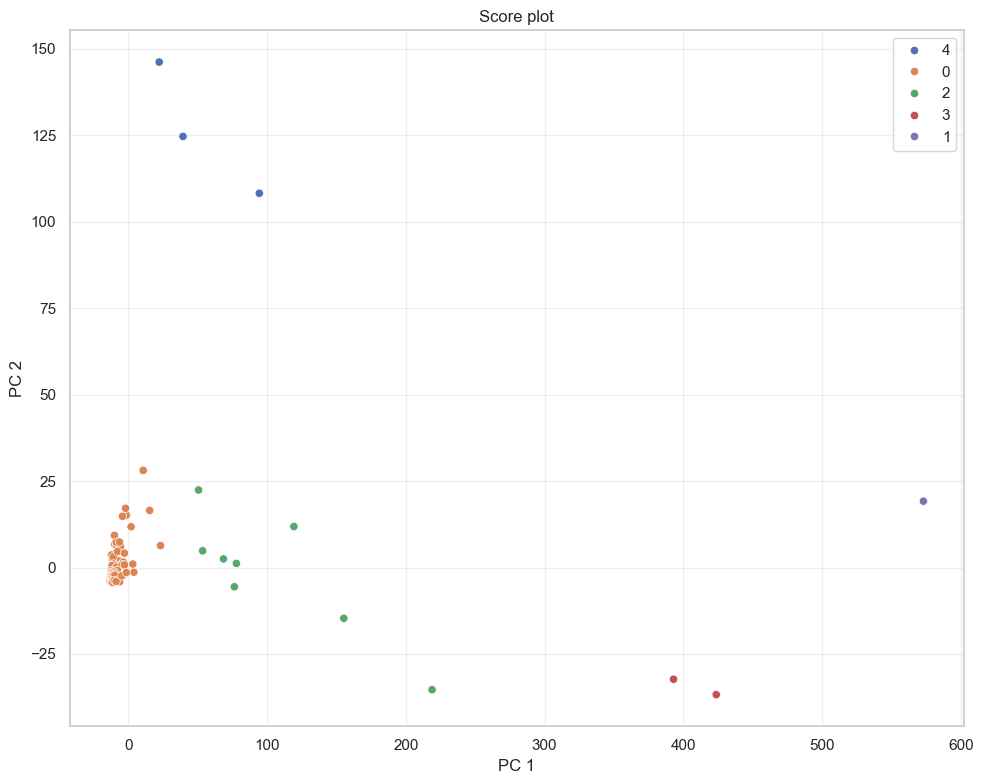

In [10]:
pca_model.kaiser_components()
k = 5
labels = list(map(str,labels_list[k - 2]))

fig = pca_model.plot_scores(score_color = labels)
plt.show()

In [11]:
anime_reaction_reviews_pca[anime_reaction_reviews_pca["PC_0"] > 500]
aa = anime_reaction_reviews.iloc[anime_reaction_reviews_pca[anime_reaction_reviews_pca["PC_0"] > 500].index].merge(anime_reviews, on = "mal_id")
print(aa["review"][0])

NameError: name 'anime_reaction_reviews_pca' is not defined

Selected components (above expected variance): 1


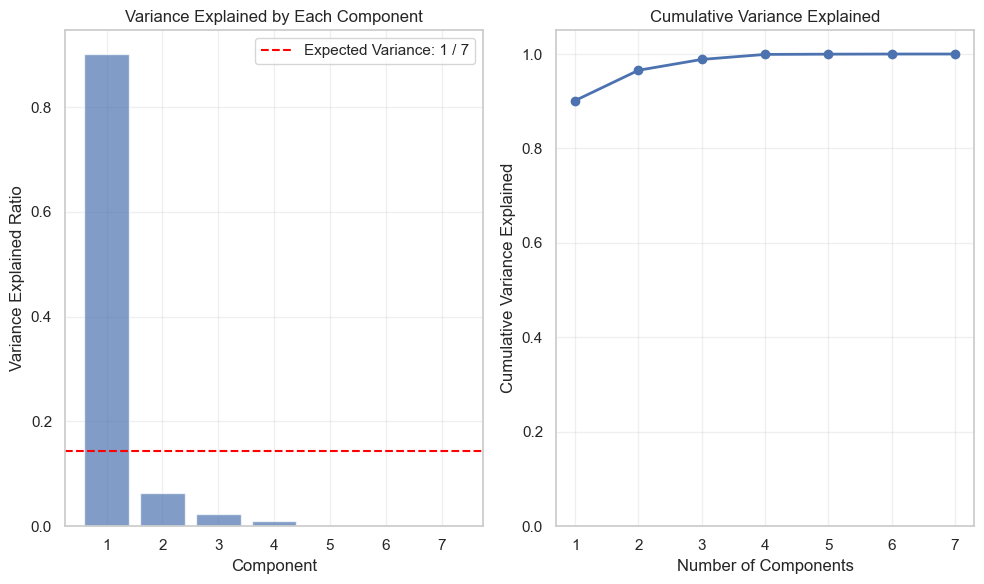

In [ ]:
# get the explained variance ratio and print it
fig = pca_model.plot_variance_explained()
plt.show()

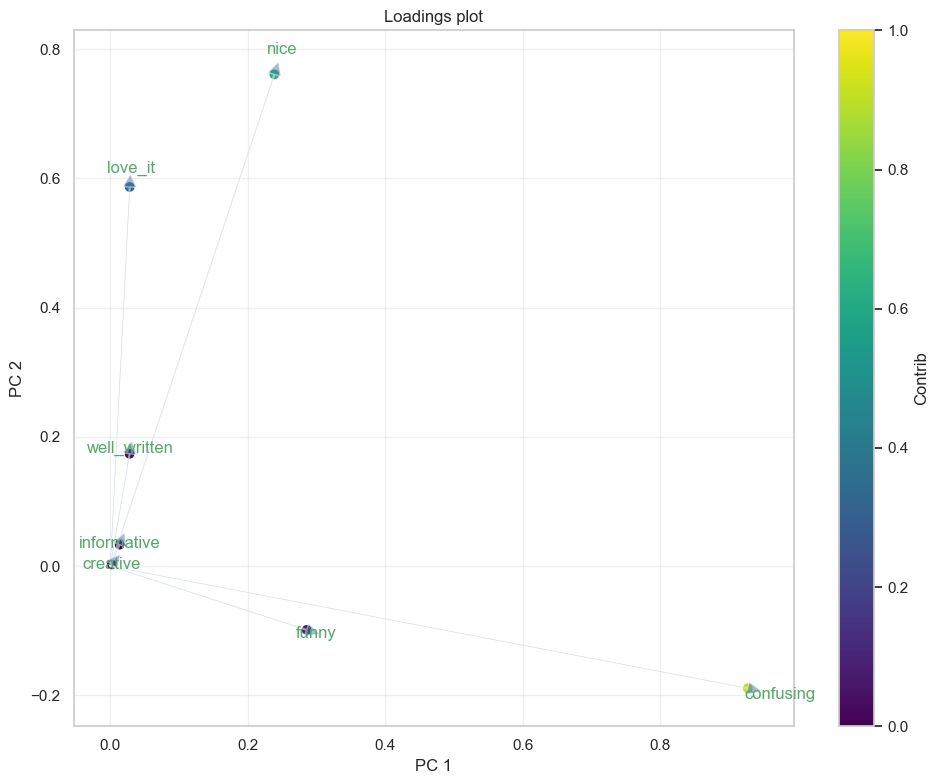

In [ ]:
fig = pca_model.plot_loadings_2d(draw_labels = True)
plt.show()

C:\Users\gonza\AppData\Local\Temp\ipykernel_9732\4082297775.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


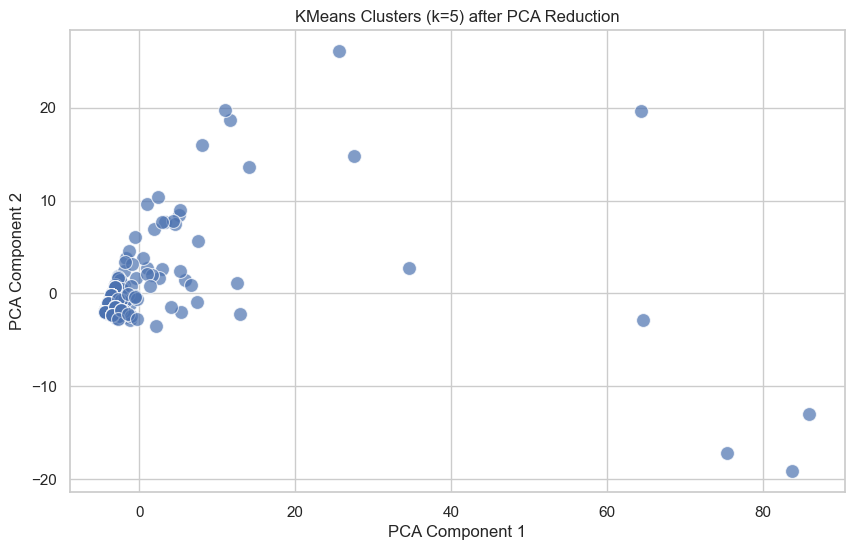

Explained variance ratio by PCA components: [8.33260270e-01 1.09853851e-01 2.68001728e-02 1.90422595e-02
 6.27751053e-03 4.63054365e-03 1.35393180e-04]


In [ ]:
anime_reaction_reviews_simple_2 = anime_reaction_reviews_simple.iloc[
    anime_reaction_reviews_pca[
    (
        (anime_reaction_reviews_pca["PC_0"] < 100)
         & (anime_reaction_reviews_pca["PC_1"] < 100)
    )
].index
]

pca_2 = PCA(n_components = 7)
anime_reaction_reviews_pca_2 = pca_2.fit_transform(anime_reaction_reviews_simple_2)
anime_reaction_reviews_pca_2 = pd.DataFrame(anime_reaction_reviews_pca_2)
anime_reaction_reviews_pca_2 = anime_reaction_reviews_pca_2.add_prefix('PC_')

k = 5
# labels = list(map(str,labels_list[k - 2]))
# anime_reaction_reviews_pca_2["labels"] = labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = anime_reaction_reviews_pca_2,
    x = 'PC_0',
    y = 'PC_1',
    # hue = 'labels',
    palette = 'Set2',
    s = 100,
    alpha = 0.7
)

plt.title(f'KMeans Clusters (k={k}) after PCA Reduction')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# get the explained variance ratio and print it
explained_variance = pca_2.explained_variance_ratio_
print("Explained variance ratio by PCA components:", explained_variance)

In [ ]:
anime_reaction_reviews_simple_2

,nice,love_it,funny,confusing,informative,well_written,creative
3,37,12,9,13,0,1,0
4,25,1,0,6,8,2,0
5,3,15,1,2,0,0,2
6,11,5,0,3,7,0,0
7,26,2,0,5,0,6,0
...,...,...,...,...,...,...,...
218,10,0,0,15,0,1,0
220,18,14,19,77,2,5,1
221,49,0,10,53,2,0,0
222,28,2,25,83,3,4,0
